In [83]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("../data/raw/healthcare-dataset-stroke-data.csv")
df.drop(columns=["id"], inplace=True)

print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df["stroke"].value_counts())
print(f"\nStroke Rate: {df['stroke'].mean()*100:.2f}%")

Dataset Shape: (5110, 11)

Class Distribution:
stroke
0    4861
1     249
Name: count, dtype: int64

Stroke Rate: 4.87%


In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   str    
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   str    
 5   work_type          5110 non-null   str    
 6   Residence_type     5110 non-null   str    
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   str    
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 439.3 KB


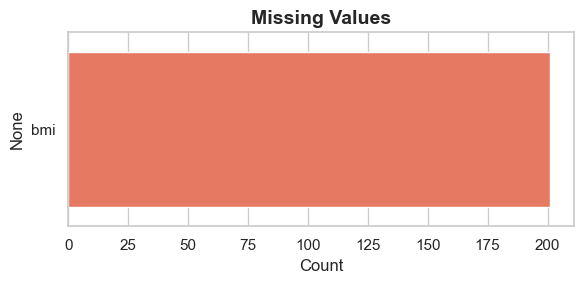

In [85]:
missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(6,3))
sns.barplot(x=missing.values, y=missing.index, palette="Reds_r")
plt.title("Missing Values", fontsize=14, fontweight="bold")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

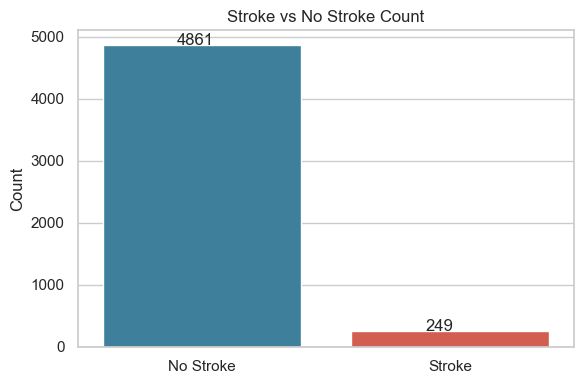

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [106]:
# How many people had stroke vs no stroke?
plt.figure(figsize=(6, 4))

ax = sns.countplot(x="stroke", data=df, hue="stroke", palette=colors, legend=False)

# Add count on top of each bar
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + 0.3, p.get_height() + 10))

plt.title("Stroke vs No Stroke Count")
plt.xticks([0, 1], ["No Stroke", "Stroke"])
plt.xlabel("")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Show percentage
print(df["stroke"].value_counts(normalize=True) * 100)

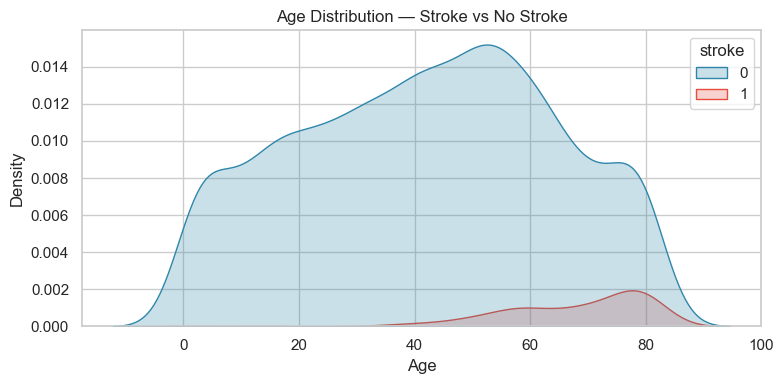

In [107]:
# Do stroke patients tend to be older?
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x="age", hue="stroke", fill=True, palette=colors)
plt.title("Age Distribution — Stroke vs No Stroke")
plt.xlabel("Age")
plt.tight_layout()
plt.show()

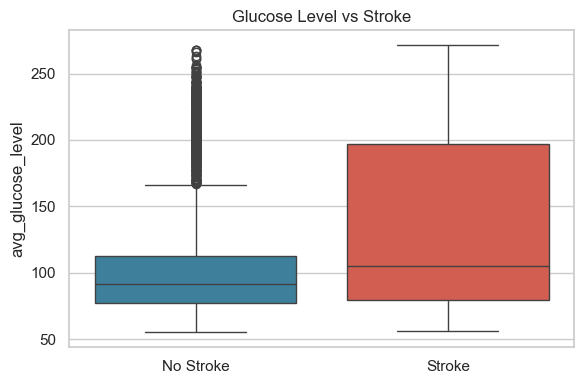

In [108]:
# Do stroke patients have higher glucose levels?
plt.figure(figsize=(6, 4))
sns.boxplot(x="stroke", y="avg_glucose_level", hue="stroke",
            data=df, palette=colors, legend=False)
plt.title("Glucose Level vs Stroke")
plt.xticks([0, 1], ["No Stroke", "Stroke"])
plt.xlabel("")
plt.tight_layout()
plt.show()

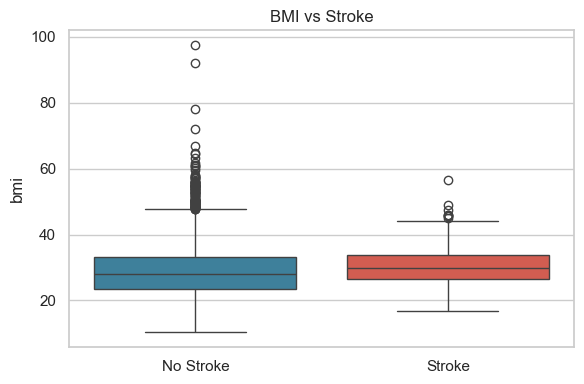

In [109]:
# Is BMI different for stroke patients?
plt.figure(figsize=(6, 4))
sns.boxplot(x="stroke", y="bmi", hue="stroke",
            data=df, palette=colors, legend=False)
plt.title("BMI vs Stroke")
plt.xticks([0, 1], ["No Stroke", "Stroke"])
plt.xlabel("")
plt.tight_layout()
plt.show()

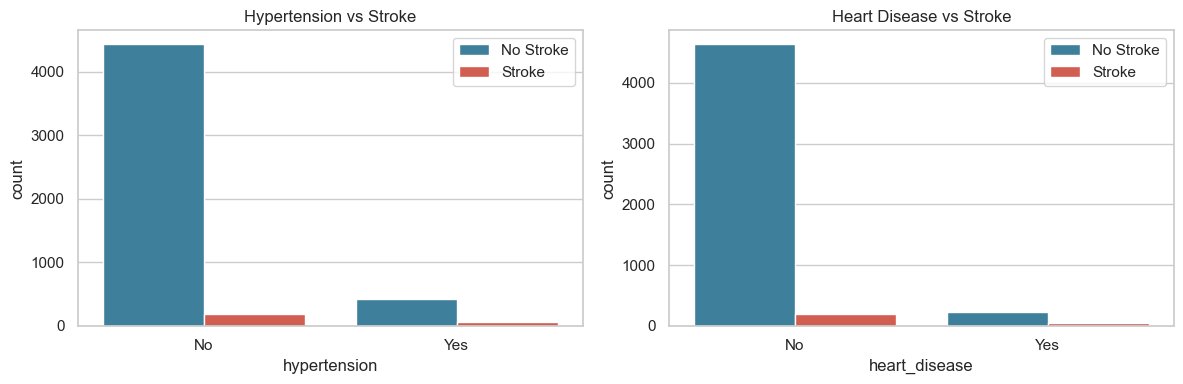

In [110]:
# Do people with hypertension or heart disease have more strokes?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x="hypertension", hue="stroke", data=df, palette=colors, ax=axes[0])
axes[0].set_title("Hypertension vs Stroke")
axes[0].set_xticklabels(["No", "Yes"])
axes[0].legend(["No Stroke", "Stroke"])

sns.countplot(x="heart_disease", hue="stroke", data=df, palette=colors, ax=axes[1])
axes[1].set_title("Heart Disease vs Stroke")
axes[1].set_xticklabels(["No", "Yes"])
axes[1].legend(["No Stroke", "Stroke"])

plt.tight_layout()
plt.show()

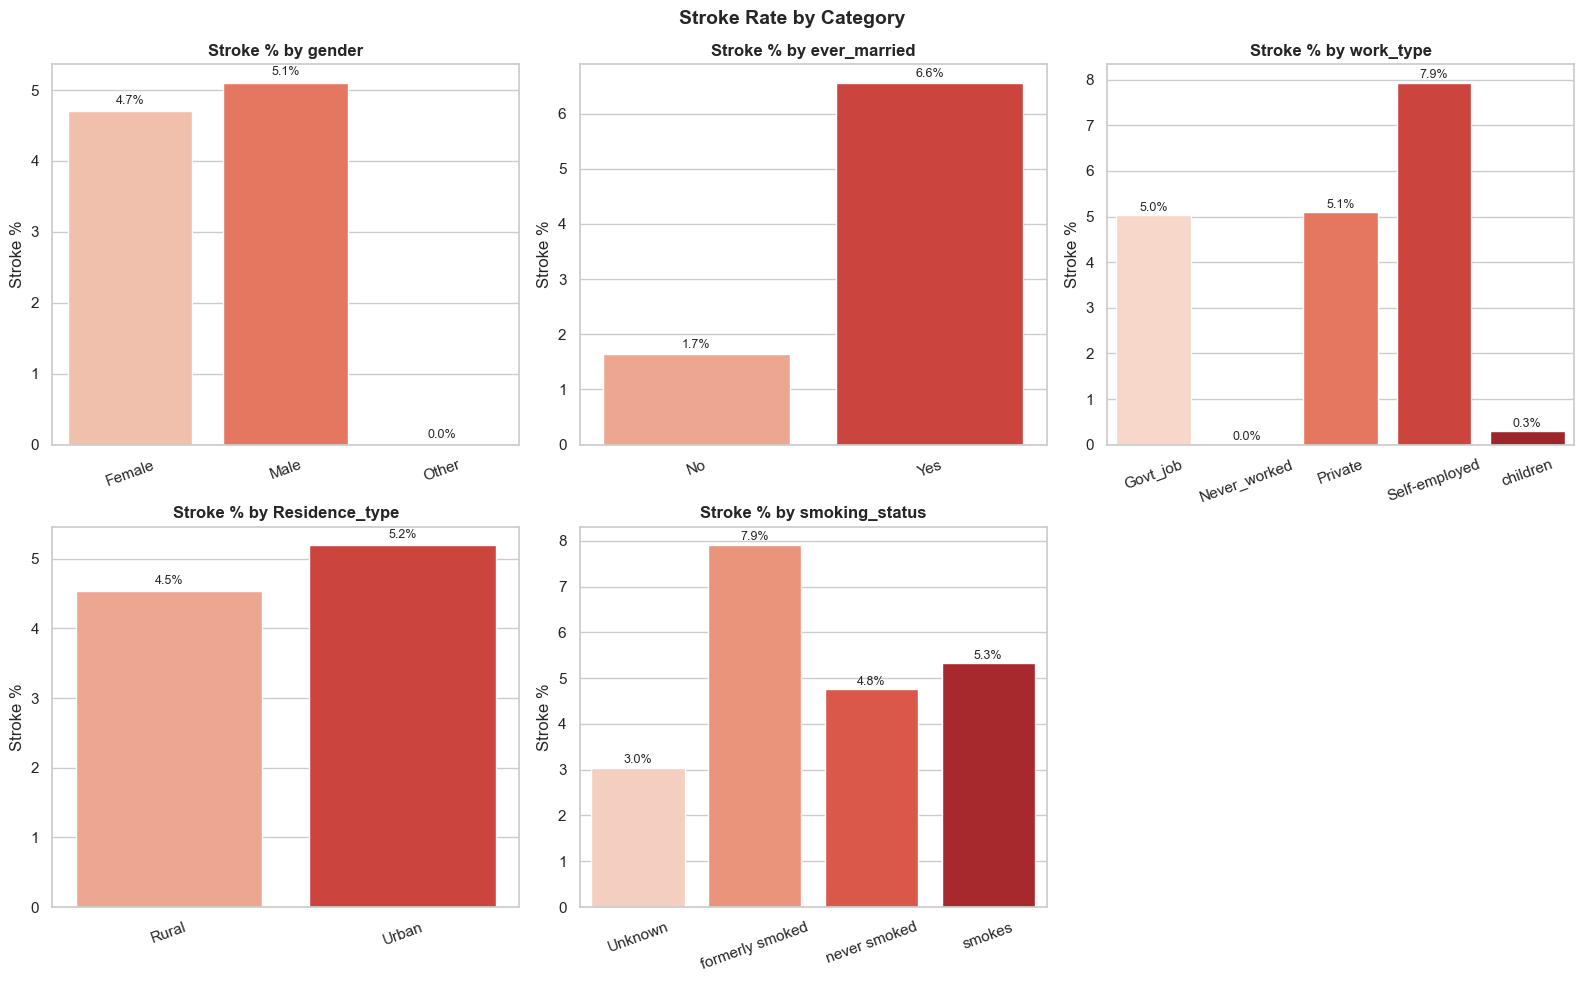

In [111]:
# What % of people in each category had a stroke?
cat_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Calculate stroke % per group
    stroke_rate = df.groupby(col)["stroke"].mean().reset_index()
    stroke_rate["stroke"] = stroke_rate["stroke"] * 100

    sns.barplot(x=col, y="stroke", data=stroke_rate, palette="Reds", ax=axes[i])

    # Add % label on each bar
    for p in axes[i].patches:
        axes[i].annotate(
            f'{p.get_height():.1f}%',
            (p.get_x() + p.get_width() / 2, p.get_height() + 0.1),
            ha="center", fontsize=9
        )

    axes[i].set_title(f"Stroke % by {col}", fontweight="bold")
    axes[i].set_ylabel("Stroke %")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=20)

# Hide last empty subplot
axes[-1].set_visible(False)

plt.suptitle("Stroke Rate by Category", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

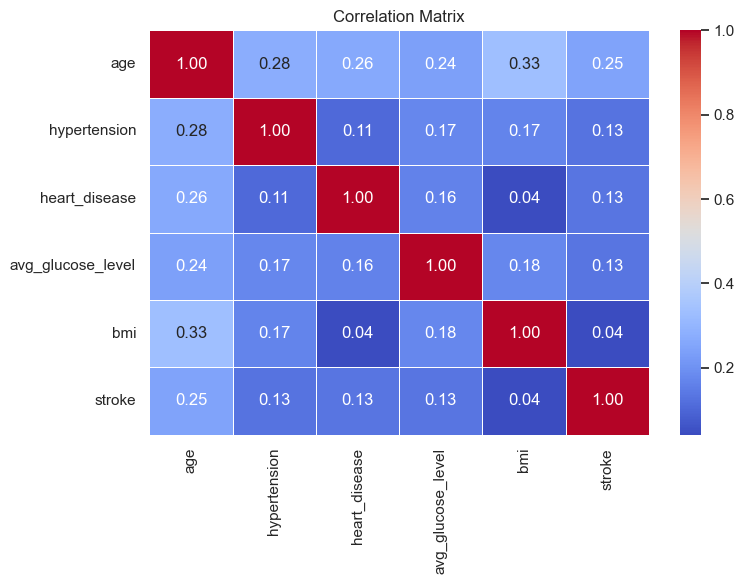

In [112]:
# Which numeric features are correlated with each other?
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True,
            fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [90]:
from sklearn.model_selection import train_test_split

X = df.drop("stroke", axis=1)
y = df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (4088, 10)
Test: (1022, 10)


In [91]:
bmi_median_train = X_train["bmi"].median()
X_train["bmi"] = X_train["bmi"].fillna(bmi_median_train)
X_test["bmi"]  = X_test["bmi"].fillna(bmi_median_train)
print(f"BMI median (train): {bmi_median_train:.2f}")
print(f"Nulls remaining: {X_train['bmi'].isnull().sum()}")

BMI median (train): 28.00
Nulls remaining: 0


In [92]:
for dataset in [X_train, X_test]:
    dataset["age_group"] = pd.cut(
        dataset["age"], bins=[0, 30, 60, 100], labels=[0, 1, 2]
    ).astype(int)
    dataset["age_hypertension"] = dataset["age"] * dataset["hypertension"]
    dataset["glucose_bmi"]      = dataset["avg_glucose_level"] * dataset["bmi"]

print("New features added: age_group, age_hypertension, glucose_bmi")
print("Train shape:", X_train.shape)

New features added: age_group, age_hypertension, glucose_bmi
Train shape: (4088, 13)


In [93]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test,  drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

bool_cols = X_train.select_dtypes("bool").columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols]  = X_test[bool_cols].astype(int)

print("Final shape:", X_train.shape)
print(X_train.dtypes)

Final shape: (4088, 19)
age                               float64
hypertension                        int64
heart_disease                       int64
avg_glucose_level                 float64
bmi                               float64
age_group                           int64
age_hypertension                  float64
glucose_bmi                       float64
gender_Male                         int64
gender_Other                        int64
ever_married_Yes                    int64
work_type_Never_worked              int64
work_type_Private                   int64
work_type_Self-employed             int64
work_type_children                  int64
Residence_type_Urban                int64
smoking_status_formerly smoked      int64
smoking_status_never smoked         int64
smoking_status_smokes               int64
dtype: object


In [94]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", dict(y_train.value_counts()))
print("After SMOTE: ", dict(y_train_res.value_counts()))

Before SMOTE: {0: np.int64(3889), 1: np.int64(199)}
After SMOTE:  {0: np.int64(3889), 1: np.int64(3889)}


In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train_scaled, y_train_res)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr  = lr.predict_proba(X_test_scaled)[:, 1]

print("=" * 40)
print("LOGISTIC REGRESSION")
print("=" * 40)
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.97      0.89      0.93       972
           1       0.19      0.50      0.28        50

    accuracy                           0.87      1022
   macro avg       0.58      0.70      0.60      1022
weighted avg       0.93      0.87      0.90      1022

ROC-AUC: 0.7759


In [96]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight="balanced"
)
rf.fit(X_train_res, y_train_res)

y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf > 0.3).astype(int)

print("=" * 40)
print("RANDOM FOREST")
print("=" * 40)
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.96      0.89      0.92       972
           1       0.11      0.26      0.15        50

    accuracy                           0.86      1022
   macro avg       0.53      0.58      0.54      1022
weighted avg       0.92      0.86      0.89      1022

ROC-AUC: 0.7568


In [97]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import recall_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators":    trial.suggest_int("n_estimators", 100, 400),
        "max_depth":       trial.suggest_int("max_depth", 3, 10),
        "learning_rate":   trial.suggest_float("learning_rate", 0.01, 0.2),
        "scale_pos_weight":trial.suggest_int("scale_pos_weight", 4, 6),
        "random_state":    42,
        "eval_metric":     "logloss"
    }
    model = XGBClassifier(**params)
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    return recall_score(y_test, y_pred)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)
print("Best params:", study.best_params)

Best params: {'n_estimators': 166, 'max_depth': 3, 'learning_rate': 0.04886698914088699, 'scale_pos_weight': 6}


In [103]:
best_model = XGBClassifier(**study.best_params, eval_metric="logloss")
best_model.fit(X_train_res, y_train_res)

y_prob_xgb = best_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb > 0.5).astype(int)

print("=" * 40)
print("XGBOOST (TUNED)")
print("=" * 40)
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

XGBOOST (TUNED)
              precision    recall  f1-score   support

           0       0.99      0.72      0.83       972
           1       0.13      0.80      0.22        50

    accuracy                           0.72      1022
   macro avg       0.56      0.76      0.53      1022
weighted avg       0.94      0.72      0.80      1022

ROC-AUC: 0.8017


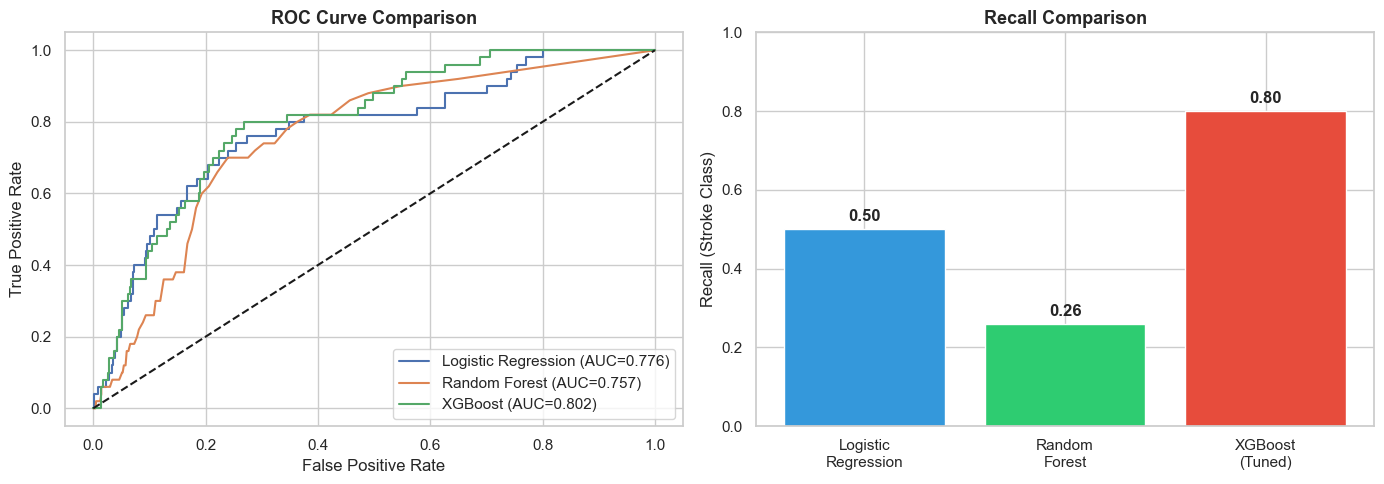

In [104]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
for name, y_prob in [("Logistic Regression", y_prob_lr),
                      ("Random Forest", y_prob_rf),
                      ("XGBoost", y_prob_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

axes[0].plot([0,1],[0,1],"k--")
axes[0].set_title("ROC Curve Comparison", fontsize=13, fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Recall comparison
models  = ["Logistic\nRegression", "Random\nForest", "XGBoost\n(Tuned)"]
recalls = [
    recall_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_xgb)
]
bars = axes[1].bar(models, recalls, color=["#3498DB", "#2ECC71", "#E74C3C"])
axes[1].set_title("Recall Comparison", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Recall (Stroke Class)")
axes[1].set_ylim(0, 1)
for bar, val in zip(bars, recalls):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02, f"{val:.2f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

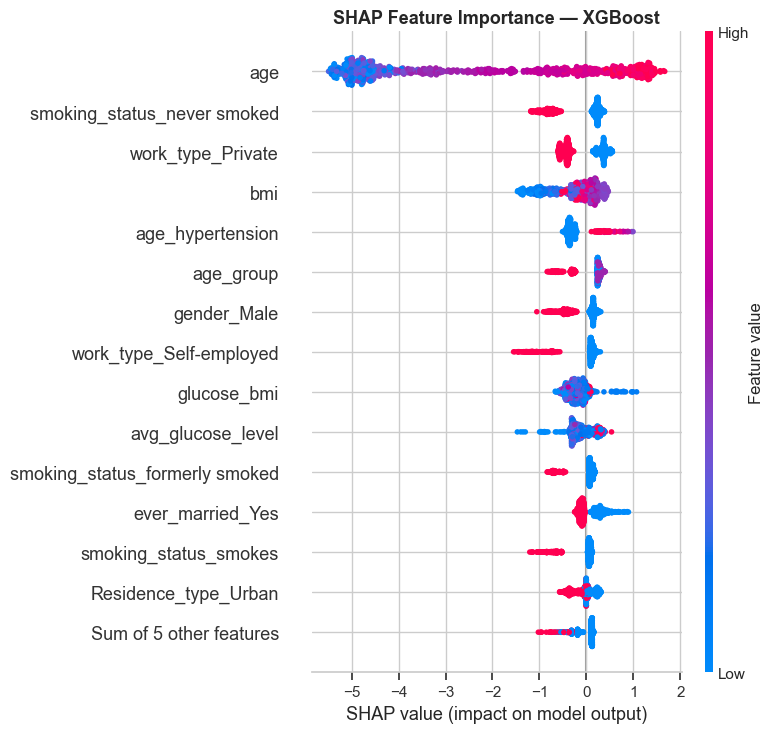

In [105]:
import shap

explainer  = shap.Explainer(best_model)
shap_values = explainer(X_test)

plt.figure()
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Feature Importance — XGBoost", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [113]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model,               "../models/stroke_model.pkl")
joblib.dump(X_train.columns.tolist(), "../models/feature_columns.pkl")
joblib.dump(0.61,                     "../models/threshold.pkl")
joblib.dump(bmi_median_train,         "../models/bmi_median.pkl")

print("Saved artifacts:")
print("  - stroke_model.pkl")
print("  - feature_columns.pkl")
print("  - threshold.pkl")
print("  - bmi_median.pkl")

Saved artifacts:
  - stroke_model.pkl
  - feature_columns.pkl
  - threshold.pkl
  - bmi_median.pkl


In [114]:
import sys
print(sys.executable)

c:\Users\Mehvish shiekh\Desktop\stroke_project\venv\Scripts\python.exe
